### I. Basic Import

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

### II. Dataset Loading and its Structure

In [2]:
path = os.path.join(os.getcwd(), 'model', 'data', 'marketing_campaign.csv')
data_str = np.loadtxt(path, delimiter=',', dtype=str)
data_gen = np.genfromtxt(path, delimiter=',', dtype=None, names=True)

In [3]:
data_gen.shape, data_str.shape

((2240,), (2241,))

In [5]:
data_gen[0:3]

array([('5524;1957;Graduation;Single;58138;0;0;2012-09-04;58;635;88;546;172;88;88;3;8;10;4;7;0;0;0;0;0;0;3;11;1',),
       ('2174;1954;Graduation;Single;46344;1;1;2014-03-08;38;11;1;6;2;1;6;2;1;1;2;5;0;0;0;0;0;0;3;11;0',),
       ('4141;1965;Graduation;Together;71613;0;0;2013-08-21;26;426;49;127;111;21;42;1;8;2;10;4;0;0;0;0;0;0;3;11;0',)],
      dtype=[('ï»¿IDYear_BirthEducationMarital_StatusIncomeKidhomeTeenhomeDt_CustomerRecencyMntWinesMntFruitsMntMeatProductsMntFishProductsMntSweetProductsMntGoldProdsNumDealsPurchasesNumWebPurchasesNumCatalogPurchasesNumStorePurchasesNumWebVisitsMonthAcceptedCmp3AcceptedCmp4AcceptedCmp5AcceptedCmp1AcceptedCmp2ComplainZ_CostContactZ_RevenueResponse', '<U109')])

In [6]:
data_str[0:3]

array(['ï»¿ID;Year_Birth;Education;Marital_Status;Income;Kidhome;Teenhome;Dt_Customer;Recency;MntWines;MntFruits;MntMeatProducts;MntFishProducts;MntSweetProducts;MntGoldProds;NumDealsPurchases;NumWebPurchases;NumCatalogPurchases;NumStorePurchases;NumWebVisitsMonth;AcceptedCmp3;AcceptedCmp4;AcceptedCmp5;AcceptedCmp1;AcceptedCmp2;Complain;Z_CostContact;Z_Revenue;Response',
       '5524;1957;Graduation;Single;58138;0;0;2012-09-04;58;635;88;546;172;88;88;3;8;10;4;7;0;0;0;0;0;0;3;11;1',
       '2174;1954;Graduation;Single;46344;1;1;2014-03-08;38;11;1;6;2;1;6;2;1;1;2;5;0;0;0;0;0;0;3;11;0'],
      dtype='<U363')

In [10]:
columns = data_str[0].split(';')
print(columns)

['ï»¿ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [12]:
len(columns)

29

There are 2240 individuals in our dataset. The dataset seems to be a set of all characteristics for each individual per 'row'. As we can see, each individual has 29 characteristics, we will call it features: 'ï»¿ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'.

In [21]:
[x[0].split(';')[0] for x in data_gen[0:3]]

['5524', '2174', '4141']

In [25]:
[x.split(";")[0] for x in data_str[1:4]]

['5524', '2174', '4141']

Data formats are not really suitable for manipulation. We need to know well how to properly manage it. We can use Numpy, but before I have to explore the data type in each 'column'.
At the end I realize it is easier and faster for me to use the EDA_app (https://huggingface.co/spaces/will-7s/eda_app) to quickly explore data type in my dataset

***'ï»¿ID' :*** data could be interpreted and transformed as numeric

***'Year_Birth':*** data could be interpreted and transformed as numeric

***'Education' :*** data could be interpreted  as categorical, as it is the customer's level of education

***'Marital_Status':*** data could be interpreted  as categorical

***'Income':*** data could be interpreted and transformed as numeric, as it's the customer’s yearly household income

***'Kidhome':*** data could be interpreted and transformed as numeric, as it is the number of small children in customer’s household 

***'Teenhome':***  data could be interpreted  as numeric or categorical, as it is the number of teenagers in customer’s household; we notice there are only 3 categories: 0, 1, or 2.
  
***'Dt_Customer':*** it is the date of customer’s enrolment with the company
  
***'Recency':*** data could be interpreted and transformed as numeric, as it's the number of days since the last purchase
  
***'MntWines':*** data could be interpreted and transformed as numeric, as it's the amount spent on wine products in the last 2 years.
It is the same for ***'MntFruits'***, ***'MntMeatProducts'***, ***'MntFishProducts'***, ***'MntSweetProducts'***, ***'MntGoldProds'***, as they are amounts spent in te last 2 years on *fruits, meat, fish, sweet, gold products*.
    
***'NumDealsPurchases':*** data could be interpreted and transformed as numeric, as it's the number of purchases made with discount

***'NumWebPurchases':*** data could be interpreted and transformed as numeric, as it's the number of purchases made through company’s web site
 
***'NumCatalogPurchases':*** data could be interpreted and transformed as numeric, as it's the number of purchases made using catalogue

***'NumStorePurchases':*** data could be interpreted and transformed as numeric, as it's the number of purchases made directly in stores

***'NumWebVisitsMonth':*** data could be interpreted and transformed as numeric, as it's the number of visits to company’s web site in the last month

***'AcceptedCmp3':*** data could be interpreted  as categorical, as it's 1 if customer accepted the offer in the 3rd campaign, 0 otherwise. 
We have the same for *'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', and 'AcceptedCmp2'*.

***'Complain':*** data could be interpreted  as categorical, as it's 1 if customer complained in the last 2 years

***'Z_CostContact':*** unique category, always 1

***'Z_Revenue':*** unique category, always 1

***'Response':*** data could be interpreted  as categorical, as it's the target i.e. 1 if customer accepted the offer in the last campaign, 0 otherwise

### III. Univariate Analysis

Here, I will only present the interesting results according to our objective. I used my EDA app for fast analysis.

#### 1. Response

In [30]:
response = [x.split(";")[-1] for x in data_str[1:]]

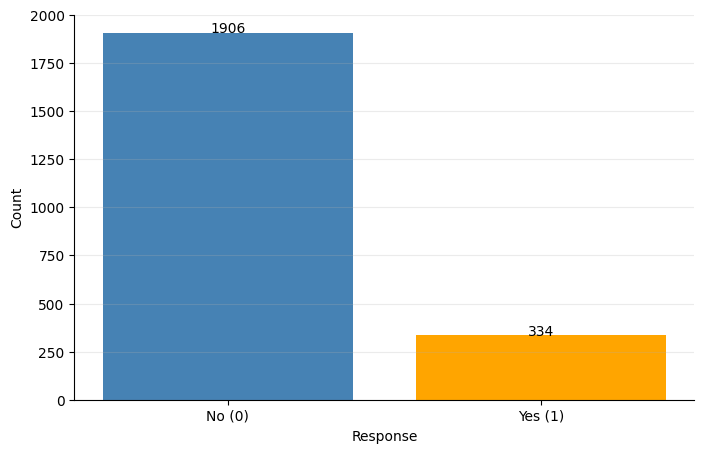

In [67]:
response_counts = [response.count('0'), response.count('1')]
response_labels = ['No (0)', 'Yes (1)']

plt.figure(figsize=(8, 5))
plt.bar(response_labels, response_counts, color=['steelblue', 'orange'])
plt.xlabel('Response')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.25)

for i, v in enumerate(response_counts):
    plt.text(i, v + 0.5, str(v), ha='center')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

There is a total of 334 'Yes' over 2 240 individuals, so the percentage is 14.9% at the end of the last campaign.

#### 2. What about accepting the offer during campaigns?

In [61]:
accepted_cmp3 = [x.split(";")[20] for x in data_str[1:]]
accepted_cmp4 = [x.split(";")[21] for x in data_str[1:]]
accepted_cmp5 = [x.split(";")[22] for x in data_str[1:]]
accepted_cmp1 = [x.split(";")[23] for x in data_str[1:]]
accepted_cmp2 = [x.split(";")[24] for x in data_str[1:]]

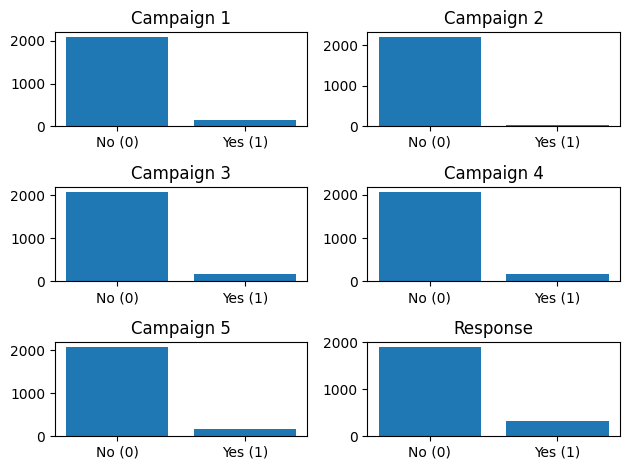

In [68]:
fig, axs = plt.subplots(3, 2)

cmp1_counts = [accepted_cmp1.count('0'), accepted_cmp1.count('1')]
cmp1_labels = ['No (0)', 'Yes (1)']
cmp2_counts = [accepted_cmp2.count('0'), accepted_cmp2.count('1')]
cmp2_labels = ['No (0)', 'Yes (1)']
cmp3_counts = [accepted_cmp3.count('0'), accepted_cmp3.count('1')]
cmp3_labels = ['No (0)', 'Yes (1)']
cmp4_counts = [accepted_cmp4.count('0'), accepted_cmp4.count('1')]
cmp4_labels = ['No (0)', 'Yes (1)']
cmp5_counts = [accepted_cmp5.count('0'), accepted_cmp5.count('1')]
cmp5_labels = ['No (0)', 'Yes (1)']

axs[0, 0].bar(cmp1_labels, cmp1_counts)
axs[0, 0].set_title("Campaign 1")

axs[0, 1].bar(cmp2_labels, cmp2_counts)
axs[0, 1].set_title("Campaign 2")

axs[1, 0].bar(cmp3_labels, cmp3_counts)
axs[1, 0].set_title("Campaign 3")

axs[1, 1].bar(cmp4_labels, cmp4_counts)
axs[1, 1].set_title("Campaign 4")

axs[2, 0].bar(cmp5_labels, cmp5_counts)
axs[2, 0].set_title("Campaign 5")

axs[2, 1].bar(response_labels, response_counts)
axs[2, 1].set_title("Response")

plt.tight_layout()
plt.show()

In [71]:
cmp1_counts[1], cmp2_counts[1], cmp3_counts[1], cmp4_counts[1], cmp5_counts[1], response_counts[1]

(144, 30, 163, 167, 163, 334)

We can observe that campaings don't have the same impact, as for instance the campaign 2 has the worst offer's accepting rate.

### IV. Bivariate Analysis


As univariate analysis, here, I will only present the interesting results according to our objective. I used my EDA app for fast analysis.

#### 1. How to explain Response?
Statistical tests (Chi-square test and Fisher's exact test) reveal that all campaings show to have a significant association with the response.

NumCatalogPurchases, NumWebPurchases, MntGoldProds, MntSweetProducts, MntFishProducts,
MntMeatProducts,  MntFruits, MntWines, Recency, Teenhome, Kidhome,
Income, Marital_status, Education

##### Complain, NumWebVisitsMonth, NumStorePurchases (fail with parametric tests and only non-parametric tests show significance), NumDealsPurchases, Year_Birth, ID

#### 2. About the Campaign 1

Response, AcceptedCmp2, AcceptedCmp5, AcceptedCmp4, AcceptedCmp3, NumWebVisitsMonth, NumStorePurchases, NumCatalogPurchases, NumWebPurchases, NumDealsPurchases, MntGoldProds,
MntSweetProducts, MntFishProducts, MntMeatProducts, MntFruits, MntWines, Teenhome, Kidhome, 
Income,

##### Complain, Recency, Marital_Status, Education, Year_Birth, ID

#### 3. About the Campaign 2

Response, AcceptedCmp1, AcceptedCmp5, AcceptedCmp4, AcceptedCmp3, NumStorePurchases

##### Complain, NumWebVisitsMonth, 